### ASSIGNMENT No: 12 

Title: TensorFlow/Pytorch implementation of CNN 

Problem Statement:  Implement TensorFlow/Pytorch implementation of CNN 

In [1]:
# This cell contains ANN-related code
# Comments are added for understanding
import numpy as np  # Import libraries
import matplotlib.pyplot as plt  # Import libraries
import tensorflow as tf  # Import libraries
from tensorflow.keras import layers, models  # Import libraries
from tensorflow.keras.datasets import cifar10  # Import libraries


In [2]:
# This cell contains ANN-related code
# Comments are added for understanding
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # Assign value

# Normalize (0–255 → 0–1)
x_train = x_train / 255.0  # Assign value
x_test = x_test / 255.0  # Assign value

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


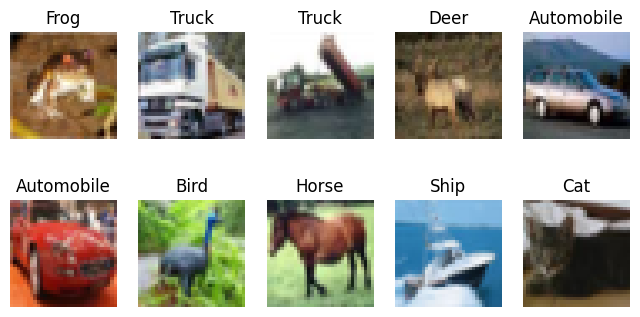

In [3]:
# This cell contains ANN-related code
# Comments are added for understanding
class_names = ['Airplane','Automobile','Bird','Cat','Deer',  # Assign value
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(8,4))  # Assign value
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [4]:
# This cell contains ANN-related code
# Comments are added for understanding
model = models.Sequential([  # Assign value
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),  # Assign value
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),  # Assign value
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),  # Assign value
    layers.Dense(10, activation='softmax')  # Assign value
])

model.compile(optimizer='adam',  # Assign value
              loss='sparse_categorical_crossentropy',  # Assign value
              metrics=['accuracy'])  # Assign value

model.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# This cell contains ANN-related code
# Comments are added for understanding
history = model.fit(  # Train model
    x_train, y_train,
    epochs=5,  # Assign value
    batch_size=64,  # Assign value
    validation_split=0.1  # Assign value
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4445 - loss: 1.5412 - val_accuracy: 0.5352 - val_loss: 1.3270
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5676 - loss: 1.2265 - val_accuracy: 0.5890 - val_loss: 1.2026
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6181 - loss: 1.0898 - val_accuracy: 0.6360 - val_loss: 1.0414
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6516 - loss: 0.9977 - val_accuracy: 0.6730 - val_loss: 0.9730
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6782 - loss: 0.9259 - val_accuracy: 0.6836 - val_loss: 0.9336


In [6]:
# This cell contains ANN-related code
# Comments are added for understanding
loss, acc = model.evaluate(x_test, y_test)  # Assign value
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6663 - loss: 0.9601
Test Accuracy: 0.6662999987602234


In [7]:
# This cell contains ANN-related code
# Comments are added for understanding
loss, acc = model.evaluate(x_test, y_test)  # Assign value
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6663 - loss: 0.9601
Test Accuracy: 0.6662999987602234


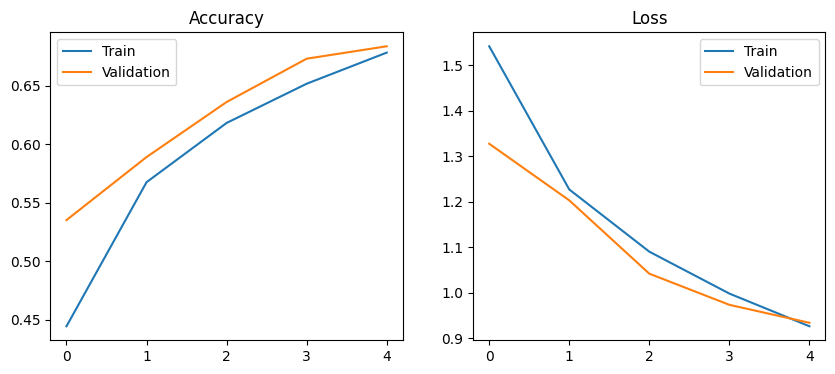

In [8]:
# This cell contains ANN-related code
# Comments are added for understanding
plt.figure(figsize=(10,4))  # Assign value

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')  # Assign value
plt.plot(history.history['val_accuracy'], label='Validation')  # Assign value
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')  # Assign value
plt.plot(history.history['val_loss'], label='Validation')  # Assign value
plt.title("Loss")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Class: Truck


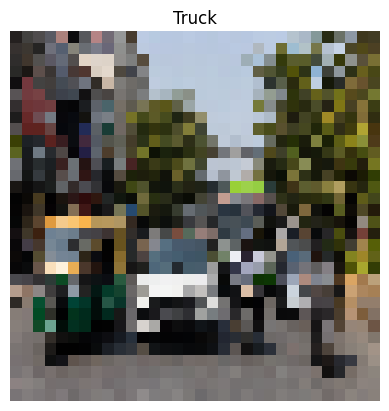

In [9]:
# This cell contains ANN-related code
# Comments are added for understanding
import cv2  # Import libraries

img = cv2.imread("image.jpg")   # keep image in folder  # Assign value
img = cv2.resize(img, (32,32))  # Assign value
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Assign value
img = img / 255.0  # Assign value

img = np.expand_dims(img, axis=0)  # Assign value

prediction = model.predict(img)  # Predict output
pred_class = class_names[np.argmax(prediction)]  # Predict output

print("Predicted Class:", pred_class)

plt.imshow(img[0])
plt.title(pred_class)
plt.axis('off')
plt.show()